<a href="https://colab.research.google.com/github/gflamiano/SJU-CSC-672-ML/blob/main/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 2


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


### 1. Load the dataset into a Pandas DataFrame.


In [46]:
DATA_URL = "https://raw.githubusercontent.com/gflamiano/SJU-CSC-672-ML/refs/heads/main/HW2/cybersecurity_intrusion_data.csv"

df = pd.read_csv(DATA_URL)
print(df.shape)


(9537, 11)


### 2. Use structural inspection methods (**`head`**`()`, **`info`**`()`, **`describe`**`()`) to analyze features such as **`network_packet_size`**, **`session_duration`**, **`login_attempts`**, **`protocol_type`**, and **`browser_type`**.


In [47]:
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [49]:
df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


### 3. Drop any non-informative identifiers.


In [50]:
non_informative = [c for c in ["session_id", "id"] if c in df.columns]
df = df.drop(columns=non_informative)
print("Dropped:", non_informative)
df.shape


Dropped: ['session_id']


(9537, 10)

I dropped `session_id` because it is just an identifier and probably won't help the model.

### 4. Quantify any **missing values** across the columns and implement a structured **imputation** strategy (using Pandas or Scikit-Learn's **`SimpleImputer`**) to handle missing entries.


In [51]:
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_summary



,missing_count,missing_pct
encryption_used,1966,20.61


There aren't any actual missing values in this sample. I still left the imputers in the pipeline in case missing values show up later.

In [52]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.drop("attack_detected").tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']
Categorical features: ['protocol_type', 'encryption_used', 'browser_type']


In [53]:
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

df_imputed = df.copy()
df_imputed[numeric_features] = num_imputer.fit_transform(df[numeric_features])
df_imputed[categorical_features] = cat_imputer.fit_transform(df[categorical_features])

print("Missing values left:", df_imputed.isna().sum().sum())


Missing values left: 0


### 5. Isolate **numerical** and **categorical** features, then build a Scikit-Learn **`ColumnTransformer`** and **`Pipeline`** that applies appropriate **scaling** (e.g., **`StandardScaler`**) to **`numerical`** columns and **encoding** (e.g., **`OneHotEncoder`**) to **`categorical`** columns.


In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

full_pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

X = df.drop(columns=["attack_detected"])
y = df["attack_detected"]

X_transformed = full_pipeline.fit_transform(X)
print("Transformed feature matrix shape:", X_transformed.shape)


Transformed feature matrix shape: (9537, 16)


### 6. Compute the **Pearson correlation** matrix for the **numerical** features, generate a Seaborn heatmap with annotations, and create at least two distribution plots and one scatter plot to examine feature relationships and the target variable (`attack_detected`).


In [55]:
corr_df = df_imputed[numeric_features + ["attack_detected"]].corr(method="pearson")
corr_df


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
network_packet_size,1.000000,-0.001890,0.021650,0.002320,-0.011676,-0.001255,-0.006798
login_attempts,-0.001890,1.000000,0.006392,-0.002618,-0.013507,0.007349,0.277320
session_duration,0.021650,0.006392,1.000000,-0.005077,0.019375,0.012930,0.041602
ip_reputation_score,0.002320,-0.002618,-0.005077,1.000000,0.015613,-0.003146,0.211540
failed_logins,-0.011676,-0.013507,0.019375,0.015613,1.000000,0.006131,0.363726
unusual_time_access,-0.001255,0.007349,0.012930,-0.003146,0.006131,1.000000,0.008652
attack_detected,-0.006798,0.277320,0.041602,0.211540,0.363726,0.008652,1.000000


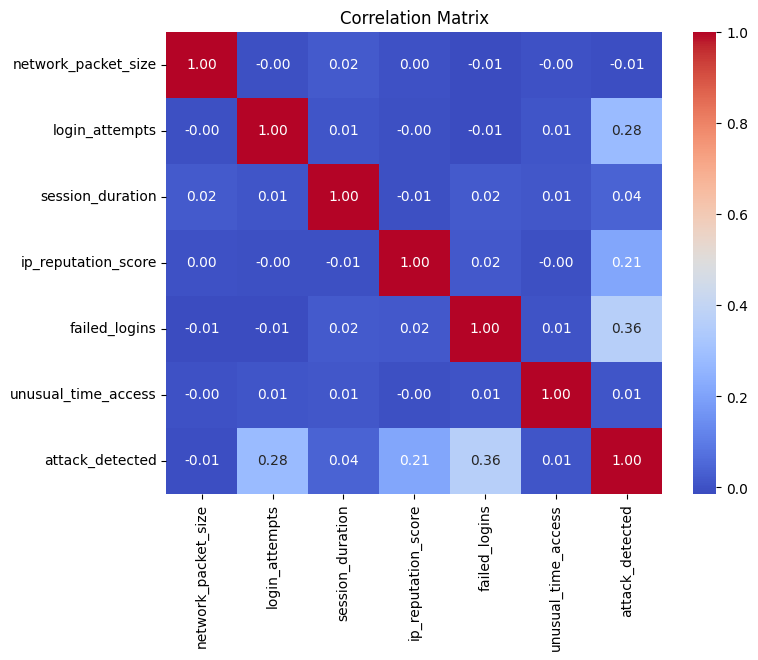

In [56]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


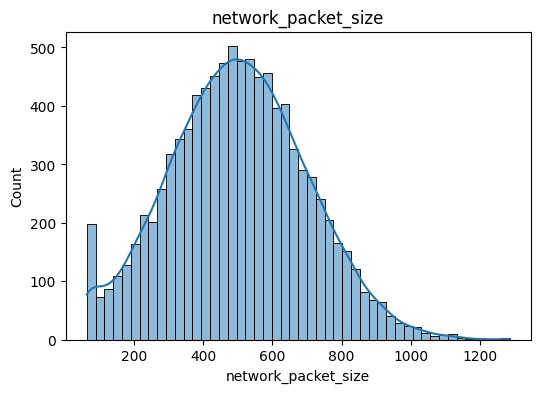

In [57]:
plt.figure(figsize=(6, 4))
sns.histplot(df_imputed["network_packet_size"], kde=True)
plt.title("network_packet_size")
plt.show()


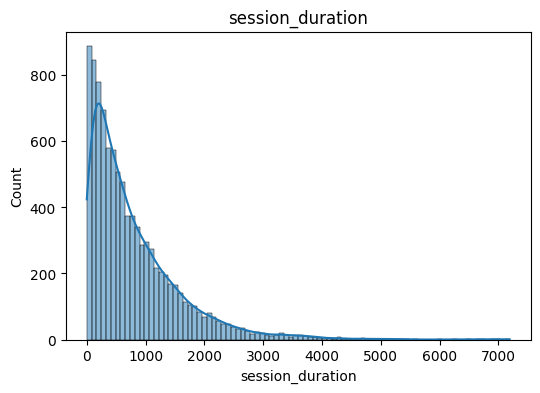

In [58]:
plt.figure(figsize=(6, 4))
sns.histplot(df_imputed["session_duration"], kde=True)
plt.title("session_duration")
plt.show()


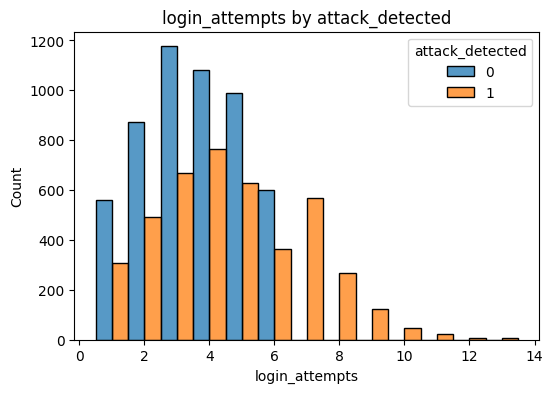

In [59]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df_imputed, x="login_attempts", hue="attack_detected", multiple="dodge", discrete=True)
plt.title("login_attempts by attack_detected")
plt.show()


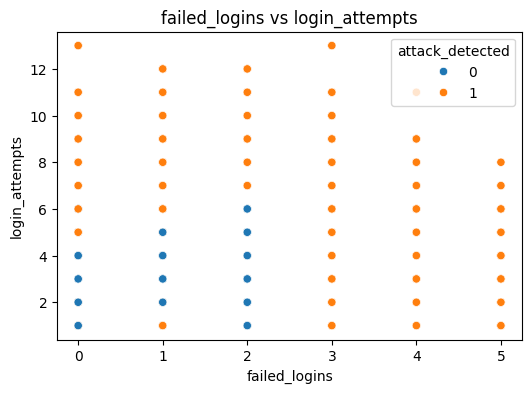

In [60]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_imputed, x="failed_logins", y="login_attempts", hue="attack_detected")
plt.title("failed_logins vs login_attempts")
plt.show()
